# Overview
We sweep over four key parameters that most influence the buy-vs-rent decision:

| Parameter | Grid Values |
|-----------|------------|
| Appreciation rate (mean) | 2%, 4%, 6%, 8% |
| Mortgage rate | 5.0%, 6.0%, 6.5%, 7.0% |
| Sell-side transaction cost | 3%, 5%, 6% |
| Home price | $400K, $600K, $800K, $1M |

For each, we run 2,000 Monte Carlo trials at horizons {1, 3, 5, 7, 10} years and record summary statistics of $\Delta(t)$.

Down payment and rent scale proportionally with home price (preserving baseline ratios); initial savings is fixed at \$100,000. Per-combo plots and summary files are saved to `results/`.

# Imports

In [1]:
from housing.sweep import build_sweep_grid, run_sweep
from housing.plotting import (
    plot_ols_coefficients, plot_partial_dependence,
    plot_joint_heatmap, plot_breakeven_heatmap,
)
from housing.params import (
    MarginalDist, StochasticParams, DeterministicParams, DEFAULT_CORRELATION,
)

from dataclasses import replace
import numpy as np
import pandas as pd

# Setup

In [2]:
stochastic_params = StochasticParams(
    appreciation=MarginalDist(mean=0.06, std=0.06),
    investment_return=MarginalDist(mean=0.07, std=0.15),
    rent_growth=MarginalDist(mean=0.03, std=0.02),
    correlation=DEFAULT_CORRELATION
)

deterministic_params = DeterministicParams(
    home_price=700_000,
    down_payment=100_000,
    interest_rate=0.065,
    loan_term_years=30,
    property_tax_rate=0.012,
    hoa_monthly=350,
    insurance_monthly=150,
    maintenance_rate=0.01,
    buy_closing_cost_rate=0.03,
    sell_transaction_cost_rate=0.06,
    rent_monthly_initial=2_500,
    initial_savings=150_000,
    monthly_income=180_000 // 12,
    ltcg_rate=0.15,
    stcg_rate=0.24,
    home_sale_exclusion=250_000,
    marginal_tax_rate=0.24,
    standard_deduction=14_600,
    salt_deduction=10_000,
)

horizons = list(range(1, 11))

In [3]:
sweep_base_det = replace(deterministic_params, initial_savings=100_000)

grid = build_sweep_grid(
    sweep_base_det,
    stochastic_params,
    appreciation_means=[0.02, 0.04, 0.06, 0.08],
    interest_rates=[0.05, 0.06, 0.065, 0.07],
    sell_cost_rates=[0.03, 0.05, 0.06],
    home_prices=[400_000, 600_000, 800_000, 1_000_000],
)

sweep_horizons = [1, 3, 5, 7, 10]
sweep_rng = np.random.default_rng(123)

# Run Parameter Sweep

In [4]:
sweep_df = run_sweep(
    grid,
    horizons=sweep_horizons,
    n_trials=10_000,
    rng=sweep_rng,
    output_dir="results",
)

  Combo 1/192 ...
  Combo 25/192 ...
  Combo 49/192 ...
  Combo 73/192 ...
  Combo 97/192 ...
  Combo 121/192 ...
  Combo 145/192 ...
  Combo 169/192 ...
  Done: 192 combos × 5 horizons = 960 rows


In [5]:
sweep_df.to_csv('results/sweep.csv')

# Sensitivity Analysis (Standardized OLS)
We fit a linear model predicting P(buy wins) and mean $\Delta$ from the four sweep parameters plus horizon. Inputs are standardized (zero-mean, unit-variance) so that coefficients are directly comparable as effect sizes.

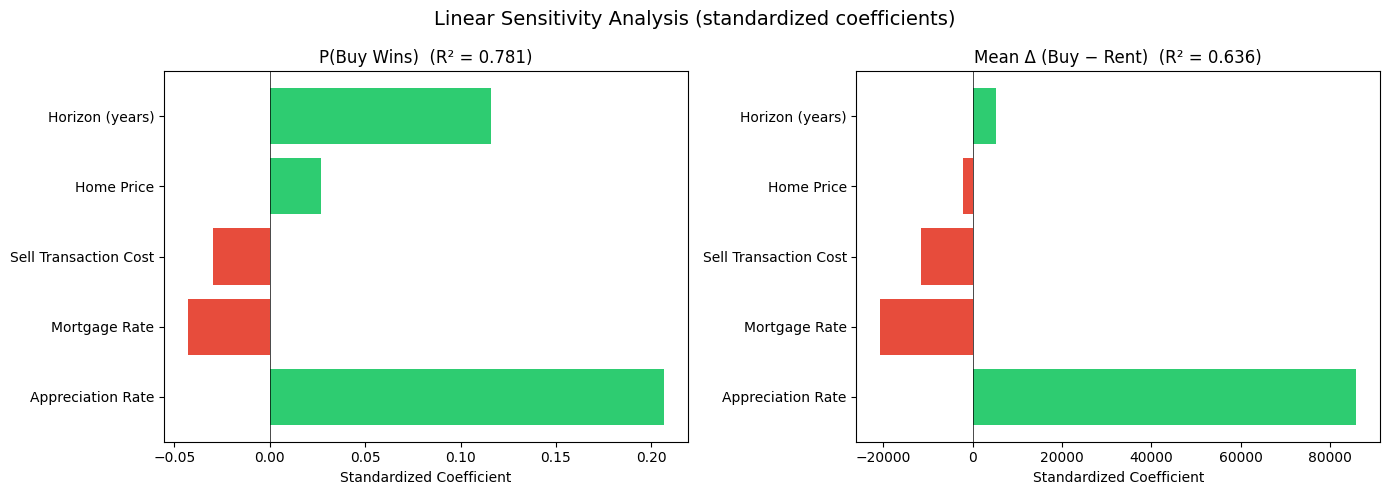

In [6]:
plot_ols_coefficients(sweep_df);

# Partial Dependence
For each parameter, we marginalize over all other parameters to show its isolated effect on P(buy wins).

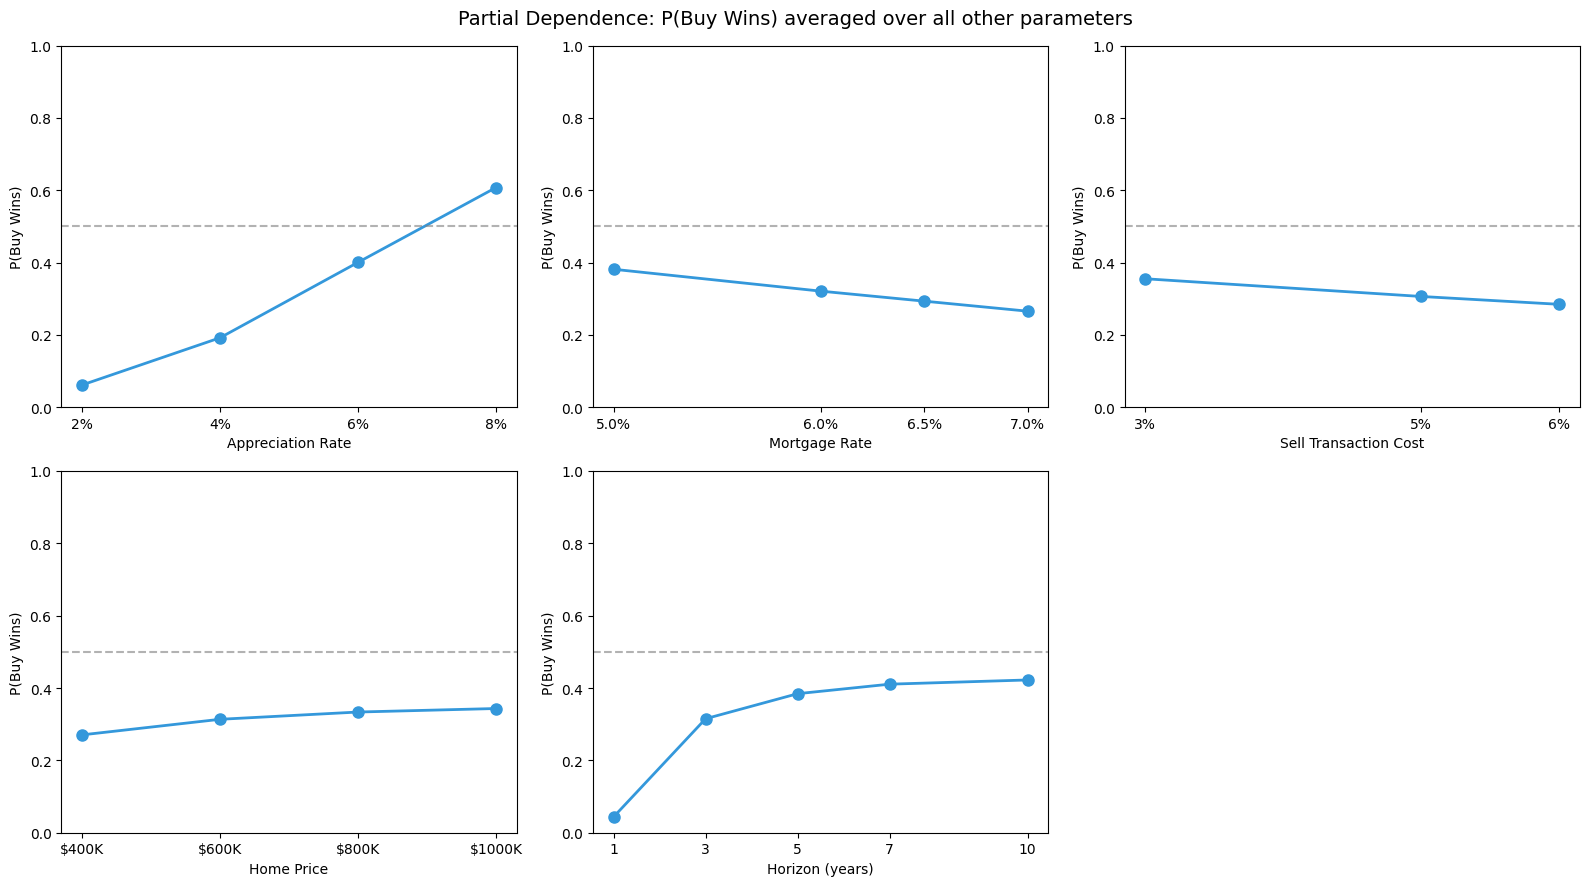

In [7]:
plot_partial_dependence(sweep_df);

# Joint Effects: Appreciation × Mortgage Rate
Heatmaps of P(buy wins) for each horizon, marginalized over home price and sell-side transaction cost.

/Users/ben/Code/housing/housing/plotting.py:234: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


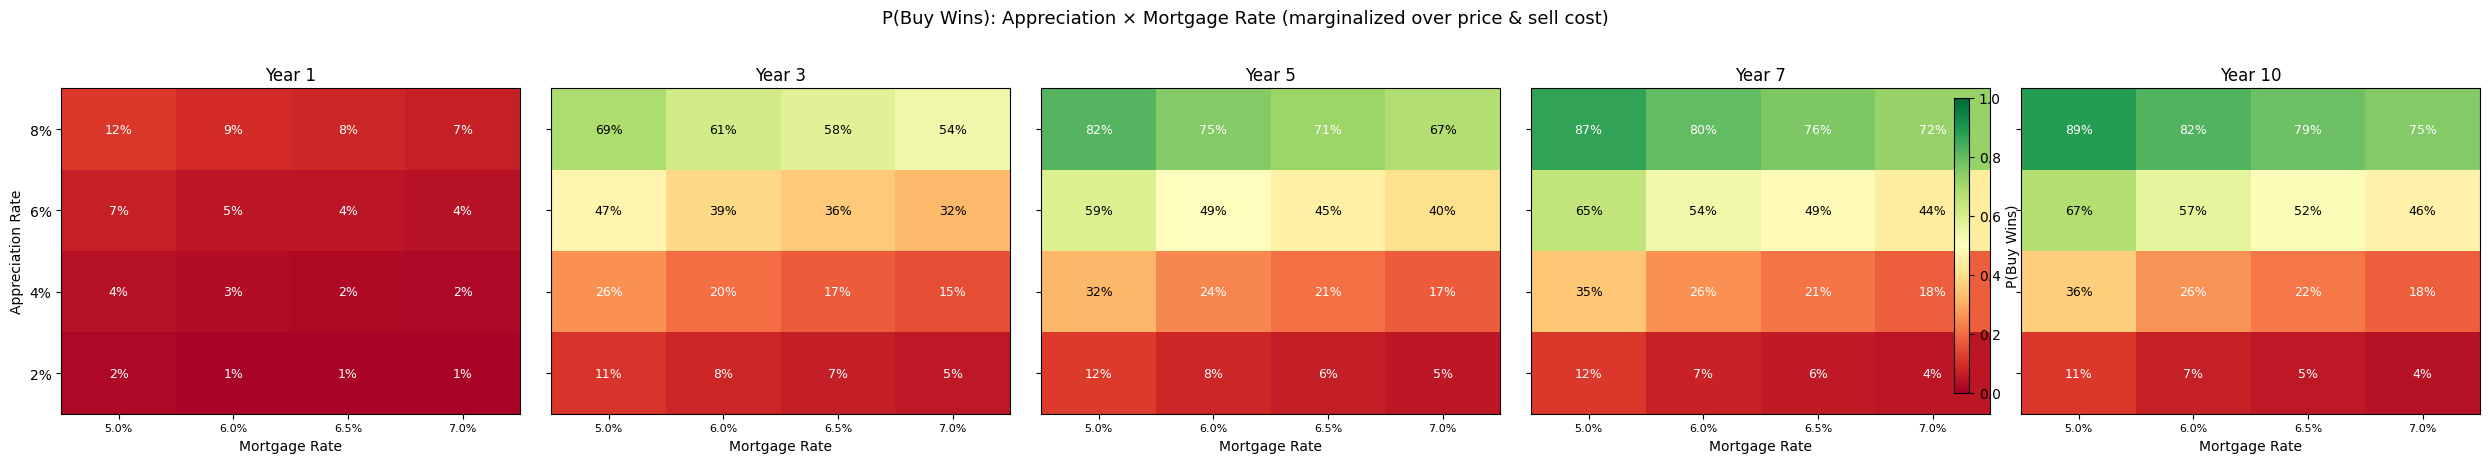

In [8]:
plot_joint_heatmap(sweep_df, horizons=sweep_horizons);

# Breakeven Horizon

For each of the parameter combinations, we linearly interpolate across horizons to find the year at which P(buy wins) first reaches 50%. The heatmap below shows this breakeven horizon as a function of appreciation and mortgage rate, averaged over home price and sell-side cost.

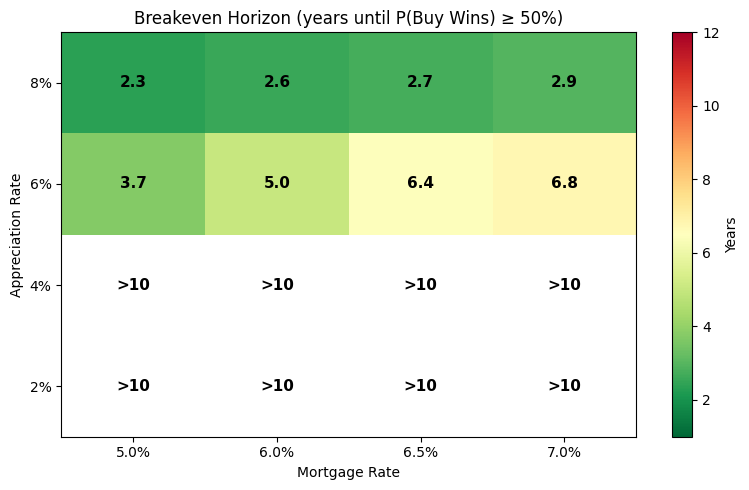

In [9]:
plot_breakeven_heatmap(sweep_df);

# Sweep Summary

## Which parameters matter most?

The standardized OLS model explains **78.1% of variance** in P(buy wins) across all scenario-horizon cells. Two parameters dominate:

| Parameter | Std. Coefficient | Direction |
|-----------|-----------------|-----------|
| **Appreciation rate** | **+0.206** | Higher appreciation strongly favors buying |
| **Horizon** | **+0.116** | Longer hold periods favor buying |
| Mortgage rate | −0.043 | Higher rates hurt buying |
| Sell transaction cost | −0.030 | Higher sell costs hurt buying |
| Home price | +0.027 | Higher prices slightly favor buying (with proportional scaling) |

Appreciation is **~5× more influential** than mortgage rate or sell costs. This makes intuitive sense: appreciation is the only mechanism that generates *wealth* for buyers (vs. merely reducing costs), and it compounds.

## Partial dependence: the thresholds that matter

The marginal P(buy wins) curves reveal critical thresholds:

- **Appreciation < 4%**: Buying almost never wins (P ≈ 6–19% averaged across all horizons). At 2% appreciation, *no combination* of mortgage rate, sell cost, or price produces a breakeven within 10 years.
- **Appreciation ≈ 6%**: Buying becomes competitive (P ≈ 40%), with breakeven horizons of 4–7 years depending on mortgage rate.
- **Appreciation ≥ 8%**: Buying is favored on average (P ≈ 61%), with breakeven as early as 2–3 years.
- **Mortgage rate** has a moderate effect: moving from 5.0% to 7.0% drops P(buy wins) from 38% to 27%.
- **Sell cost** has a smaller but meaningful effect: 3% vs 6% shifts P(buy wins) by ~7 percentage points.
- **Home price** has very little marginal effect once proportional scaling is applied — the decision is scale-invariant in this model.

## Joint effects and breakeven

The appreciation × mortgage rate heatmaps show that:
- At **8% appreciation / 5.0% mortgage**: buying wins in **~12% of simulations at year 1**, rising to **~89%** by year 10.
- At **6% appreciation / 6.5% mortgage** (the baseline): buying is a **coin flip at ~6–7 years**.
- At **4% appreciation / 7.0% mortgage**: buying never reaches 50% within the 10-year window.

The breakeven heatmap confirms that only the upper-left quadrant (high appreciation, low rates) produces breakevens within our horizon:

| | 5.0% rate | 6.0% rate | 6.5% rate | 7.0% rate |
|---|---|---|---|---|
| **8% appreciation** | 2.3 yr | 2.6 yr | 2.7 yr | 2.9 yr |
| **6% appreciation** | 3.7 yr | 5.0 yr | 6.4 yr | 6.8 yr |
| **4% appreciation** | >10 yr | >10 yr | >10 yr | >10 yr |
| **2% appreciation** | >10 yr | >10 yr | >10 yr | >10 yr |

## Key takeaways

1. **The buy-vs-rent decision is overwhelmingly an appreciation bet.** If you believe your local market will appreciate at ≥6% annually, buying becomes favorable at a 5–7 year horizon. Below 4%, renting dominates regardless of other parameters.

2. **Transaction costs create a ~2-year dead zone.** Even under the most optimistic parameters (8% appreciation, 5% mortgage, 3% sell cost), buying needs ~2 years to overcome the upfront drag.

3. **The decision is approximately scale-invariant.** A \$400K and \$1M home produce similar P(buy wins) when down payment and rent are proportional — the absolute dollar magnitudes differ but the *decision* doesn't change much.

4. **Mortgage rate matters less than you'd think.** The spread between 5.0% and 7.0% shifts breakeven by only ~1–3 years. Waiting for a lower rate is less important than the appreciation outlook of the market you're buying into.